In [1]:
import os

# Set the current working directory to /content
os.chdir('/content/drive/MyDrive/SmartVision_AI')

# Verify the current working directory
print(f"Current working directory: {os.getcwd()}")

Current working directory: /content/drive/MyDrive/SmartVision_AI


Attempting to load dataset from: /content/drive/MyDrive/SmartVision_AI/data/classification/train
Found 1820 images across 26 categories.
Starting comprehensive image classification dataset analysis...

--- 1. Analyzing Class Distribution (Images per Class) ---
Class Counts:
     Category  Count
     airplane     70
          bed     70
        bench     70
      bicycle     70
         bird     70
       bottle     70
         bowl     70
          bus     70
         cake     70
          car     70
          cat     70
        chair     70
        couch     70
          cow     70
          cup     70
          dog     70
     elephant     70
        horse     70
   motorcycle     70
       person     70
        pizza     70
 potted plant     70
    stop sign     70
traffic light     70
        train     70
        truck     70


/tmp/ipykernel_1084/1495974511.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Count', data=class_counts_df, palette='viridis')


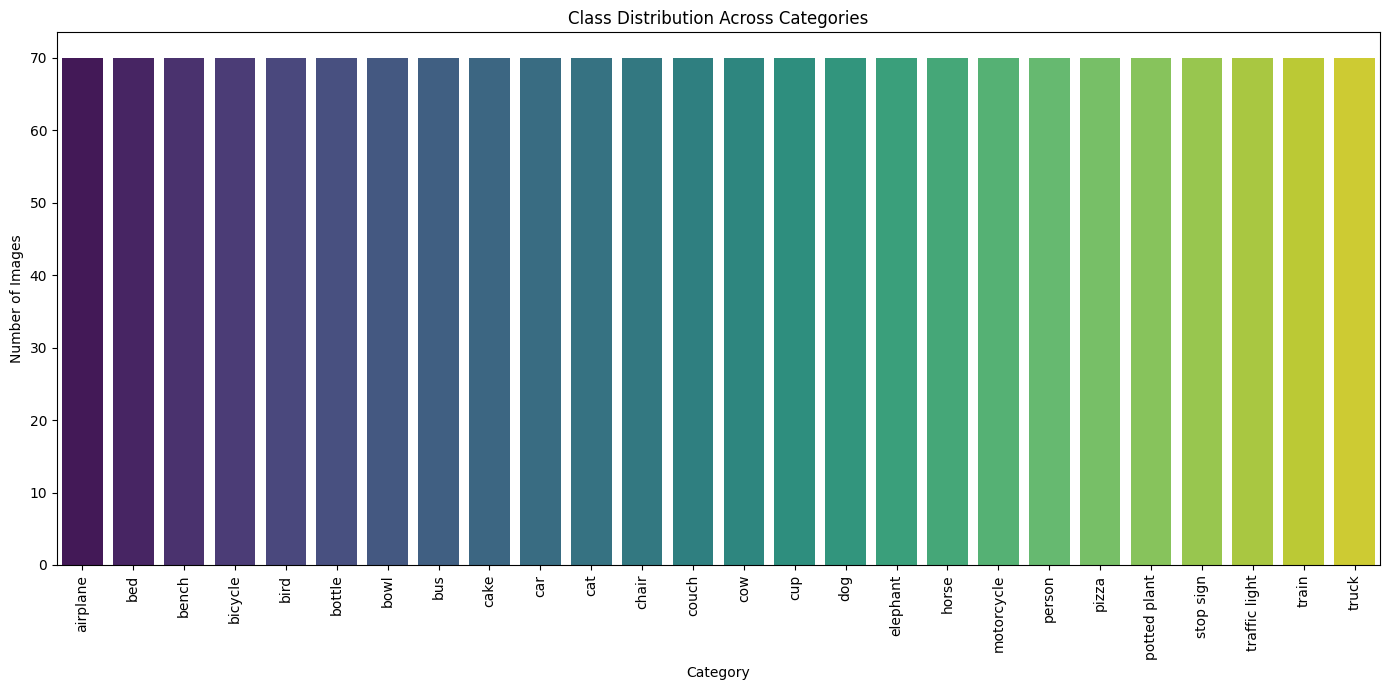


--- 2. Examining Image Characteristics and Quality ---
Analyzed 500 image dimensions from a sample of 500 images.
Average Image Width: 224.00 pixels
Average Image Height: 224.00 pixels
Min Image Width: 224 pixels
Max Image Width: 224 pixels
Min Image Height: 224 pixels
Max Image Height: 224 pixels


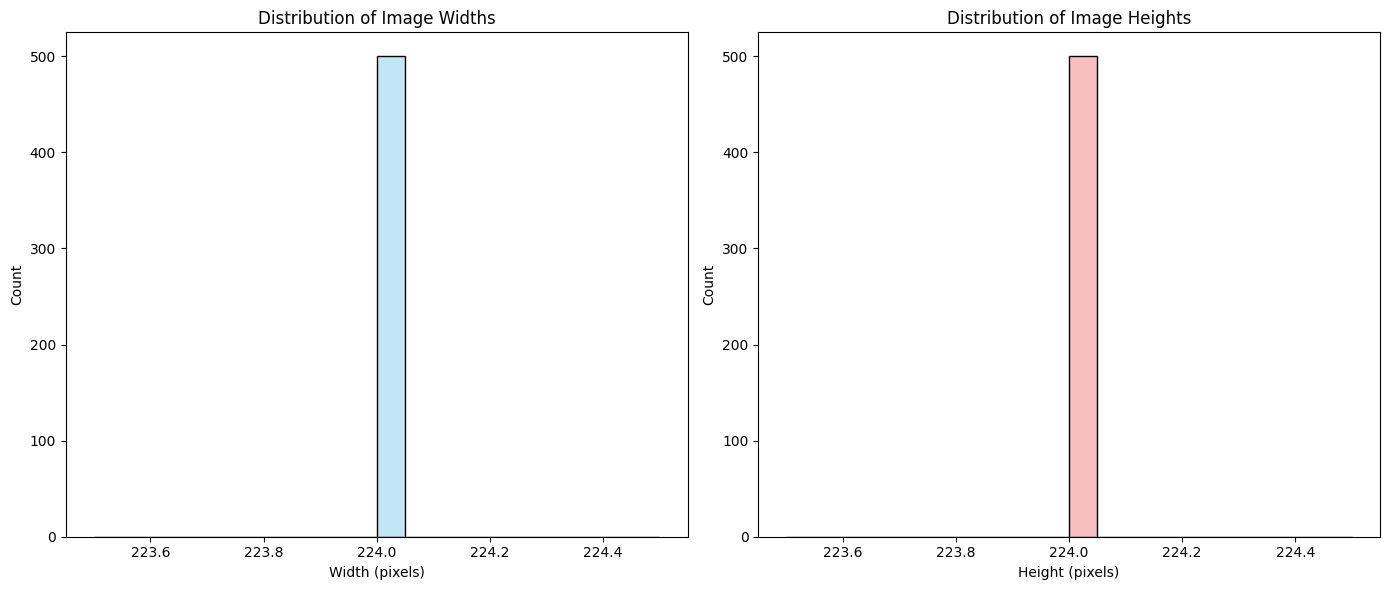


--- Image Quality Discussion (Conceptual) ---
For a classification task, image quality assessment would involve considering:
-  **Resolution Consistency**: Are images generally high-resolution or low-resolution? Very mixed resolutions might impact model performance.
-  **Visual Clarity**: Are images generally sharp, well-lit, and in focus? Blurry, dark, or overexposed images can hinder classification.
-  **Image Content**: Does the image clearly depict the object of its class without excessive clutter or irrelevant elements? (e.g., 'airplane' folder has actual airplanes, not just sky with a tiny dot). 
These factors often require human inspection or more advanced image processing techniques (e.g., using libraries like OpenCV to calculate blur metrics). 

--- 3. Visualizing Sample Images with Class Labels (showing 5 samples) ---


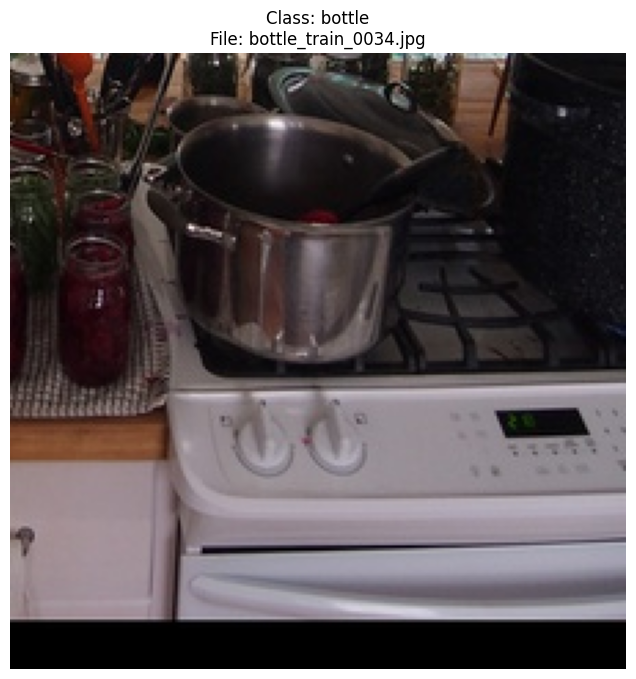

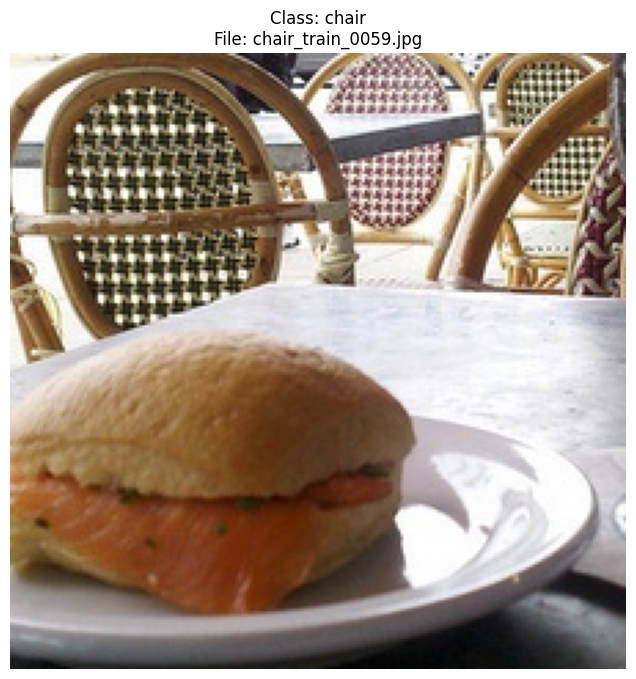

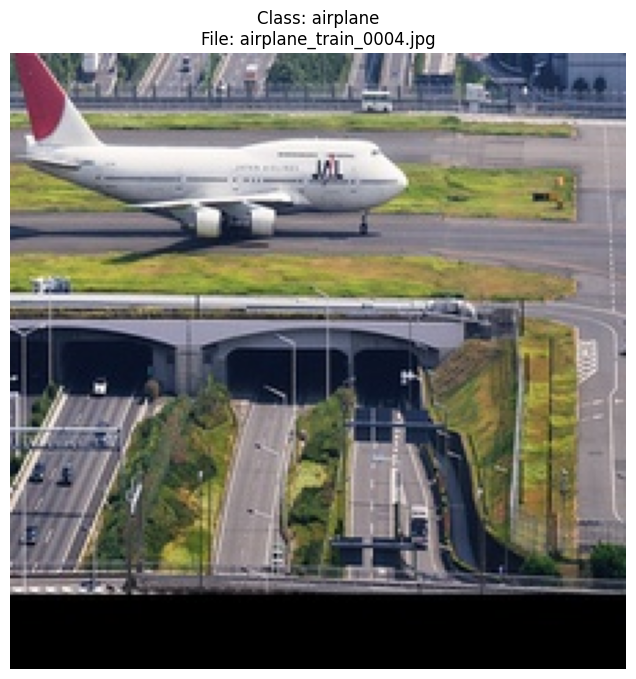

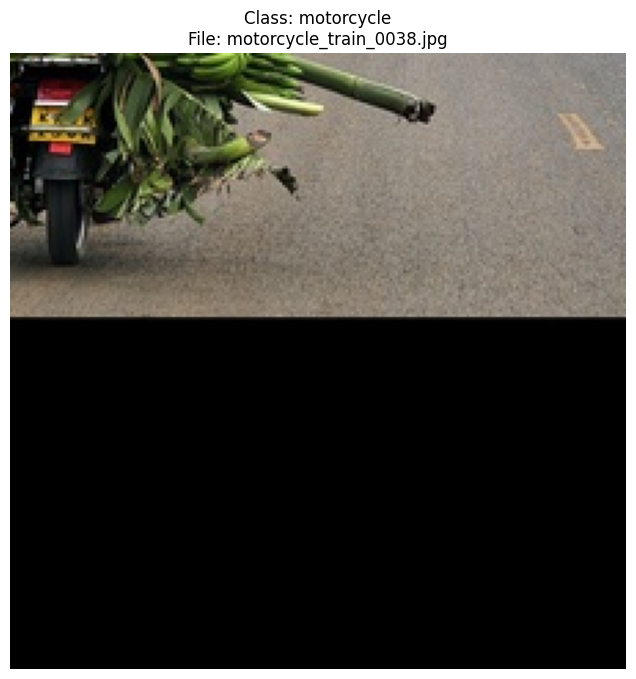

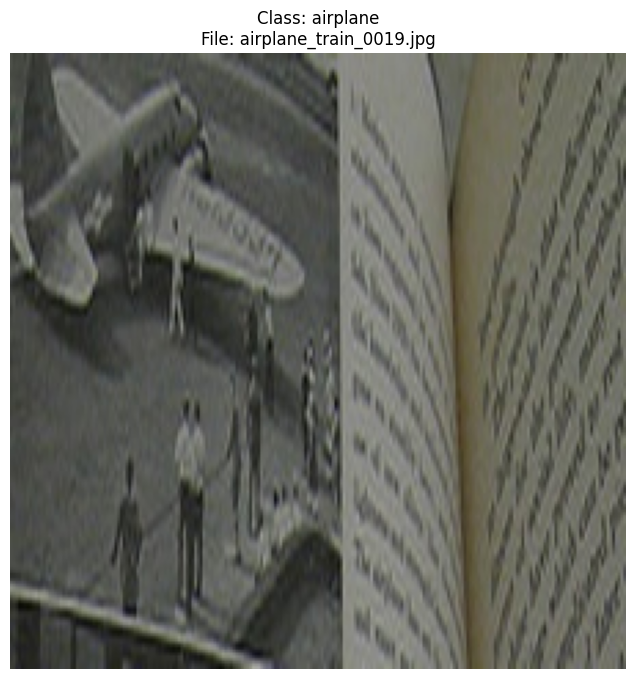


--- 4. Verifying Class Balance ---
Class Proportions:
     Category  Count  Proportion
     airplane     70    3.846154
          bed     70    3.846154
        bench     70    3.846154
      bicycle     70    3.846154
         bird     70    3.846154
       bottle     70    3.846154
         bowl     70    3.846154
          bus     70    3.846154
         cake     70    3.846154
          car     70    3.846154
          cat     70    3.846154
        chair     70    3.846154
        couch     70    3.846154
          cow     70    3.846154
          cup     70    3.846154
          dog     70    3.846154
     elephant     70    3.846154
        horse     70    3.846154
   motorcycle     70    3.846154
       person     70    3.846154
        pizza     70    3.846154
 potted plant     70    3.846154
    stop sign     70    3.846154
traffic light     70    3.846154
        train     70    3.846154
        truck     70    3.846154


/tmp/ipykernel_1084/1495974511.py:190: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Proportion', data=class_proportions_df, palette='magma')


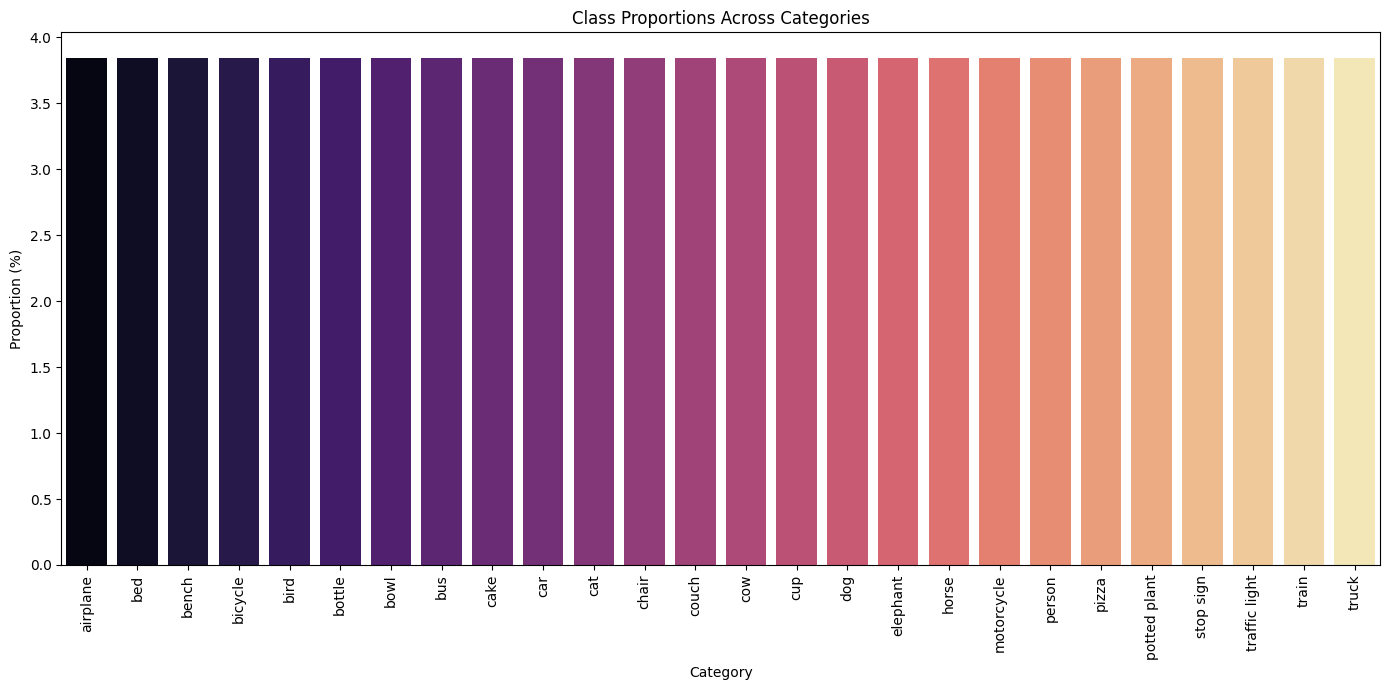

Standard Deviation of Class Proportions: 0.00 percentage points
Range of Class Proportions: 3.85% - 3.85%

Class distribution appears relatively balanced, or the imbalance is minor.

--- Analysis Complete ---


In [2]:
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np
import pandas as pd

# --- Configuration and Data Loading ---

# The root directory for your classification data
# This assumes the structure: DATA_ROOT/class_name/image.jpg
DATA_ROOT = os.path.join(os.getcwd(), 'data', 'classification', 'train')

# Function to load classification dataset from directory structure
def load_classification_dataset(data_root_path):
    print(f"Attempting to load dataset from: {data_root_path}")
    dataset = []
    found_categories = []

    # Check if the data root exists
    if not os.path.isdir(data_root_path):
        print(f"Error: Data root directory not found at '{data_root_path}'.\n" \
              "Please ensure the path is correct and the directory exists.")
        return [], []

    for class_name in sorted(os.listdir(data_root_path)):
        class_dir = os.path.join(data_root_path, class_name)
        if os.path.isdir(class_dir):
            found_categories.append(class_name)
            for image_file in os.listdir(class_dir):
                if image_file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                    image_path = os.path.join(class_dir, image_file)
                    dataset.append({
                        'image_path': image_path,
                        'class_name': class_name
                    })
    if not dataset:
        print(f"No image files (png, jpg, jpeg, gif, bmp) found in '{data_root_path}' or its subdirectories.")
    else:
        print(f"Found {len(dataset)} images across {len(found_categories)} categories.")
    return dataset, found_categories

# Load the actual dataset
classification_dataset, categories = load_classification_dataset(DATA_ROOT)

# Fallback to dummy data if actual loading fails or no images are found
if not classification_dataset:
    print("Generating dummy data for analysis as no real data was loaded or found.")
    dummy_categories = [f'category_{i}' for i in range(25)] # Assuming 25 categories as per initial request
    dummy_dataset_classification = []
    for i in range(100): # Create 100 dummy images
        dummy_dataset_classification.append({
            'image_path': f'/content/drive/MyDrive/SmartVision_AI/data/classification/train/dummy_class/image_{i:04d}.jpg', # Placeholder path
            'class_name': random.choice(dummy_categories)
        })
    classification_dataset = dummy_dataset_classification
    categories = dummy_categories
    print(f"Generated dummy dataset with {len(classification_dataset)} images.")


# --- Analysis Functions ---

def analyze_class_distribution(dataset, categories_list):
    """Analyzes and visualizes the distribution of classes (images per class)."""
    print("\n--- 1. Analyzing Class Distribution (Images per Class) ---")
    class_counts = {cat: 0 for cat in categories_list} # Initialize with all found categories
    for img_info in dataset:
        if img_info['class_name'] in class_counts:
            class_counts[img_info['class_name']] += 1
        else:
            # If a class from dummy data or unexpected class appears
            class_counts[img_info['class_name']] = 1

    class_counts_df = pd.DataFrame(class_counts.items(), columns=['Category', 'Count'])
    class_counts_df = class_counts_df.sort_values(by='Count', ascending=False)

    print("Class Counts:\n" + class_counts_df.to_string(index=False))

    plt.figure(figsize=(14, 7))
    sns.barplot(x='Category', y='Count', data=class_counts_df, palette='viridis')
    plt.xticks(rotation=90)
    plt.title('Class Distribution Across Categories')
    plt.xlabel('Category')
    plt.ylabel('Number of Images')
    plt.tight_layout()
    plt.show()
    return class_counts

def analyze_image_characteristics(dataset):
    """Examines image characteristics like dimensions and discusses quality (illustrative)."""
    print("\n--- 2. Examining Image Characteristics and Quality ---")
    widths = []
    heights = []

    # Process only a sample of images for efficiency if dataset is huge
    sample_size = min(len(dataset), 500) # Analyze up to 500 images for characteristics
    sampled_dataset = random.sample(dataset, sample_size)

    for img_info in sampled_dataset:
        try:
            with Image.open(img_info['image_path']) as img:
                widths.append(img.width)
                heights.append(img.height)
        except FileNotFoundError:
            # This might happen if using dummy data with non-existent paths, or real data missing
            pass # Skip and continue silently for this specific error
        except Exception as e:
            print(f"Could not read image {img_info['image_path']}: {e}")

    if not widths:
        print("No image dimensions could be read from the sampled dataset. Ensure image files exist at their specified paths.")
        return

    print(f"Analyzed {len(widths)} image dimensions from a sample of {sample_size} images.")
    print(f"Average Image Width: {np.mean(widths):.2f} pixels")
    print(f"Average Image Height: {np.mean(heights):.2f} pixels")
    print(f"Min Image Width: {np.min(widths)} pixels")
    print(f"Max Image Width: {np.max(widths)} pixels")
    print(f"Min Image Height: {np.min(heights)} pixels")
    print(f"Max Image Height: {np.max(heights)} pixels")

    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    sns.histplot(widths, bins=20, kde=True, color='skyblue')
    plt.title('Distribution of Image Widths')
    plt.xlabel('Width (pixels)')
    plt.ylabel('Count')

    plt.subplot(1, 2, 2)
    sns.histplot(heights, bins=20, kde=True, color='lightcoral')
    plt.title('Distribution of Image Heights')
    plt.xlabel('Height (pixels)')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    print("\n--- Image Quality Discussion (Conceptual) ---")
    print("For a classification task, image quality assessment would involve considering:")
    print("-  **Resolution Consistency**: Are images generally high-resolution or low-resolution? Very mixed resolutions might impact model performance.")
    print("-  **Visual Clarity**: Are images generally sharp, well-lit, and in focus? Blurry, dark, or overexposed images can hinder classification.")
    print("-  **Image Content**: Does the image clearly depict the object of its class without excessive clutter or irrelevant elements? (e.g., 'airplane' folder has actual airplanes, not just sky with a tiny dot). ")
    print("These factors often require human inspection or more advanced image processing techniques (e.g., using libraries like OpenCV to calculate blur metrics). ")


def visualize_sample_images_with_labels(dataset, num_samples=5):
    """Visualizes sample images with their assigned class labels."""
    print(f"\n--- 3. Visualizing Sample Images with Class Labels (showing {num_samples} samples) ---")

    if not dataset:
        print("No images in dataset to display.")
        return

    sample_images_info = random.sample(dataset, min(num_samples, len(dataset)))

    for img_info in sample_images_info:
        try:
            img = Image.open(img_info['image_path'])
            plt.figure(figsize=(8, 8))
            plt.imshow(img)
            plt.title(f"Class: {img_info['class_name']}\nFile: {os.path.basename(img_info['image_path'])}")
            plt.axis('off')
            plt.show()
        except FileNotFoundError:
            print(f"Warning: Image file not found at {img_info['image_path']}. Cannot display this sample.")
        except Exception as e:
            print(f"Error loading or displaying image {img_info['image_path']}: {e}")


def verify_class_balance(class_counts):
    """Verifies class balance based on the class distribution."""
    print("\n--- 4. Verifying Class Balance ---")
    total_instances = sum(class_counts.values())
    if total_instances == 0:
        print("No instances found across any class. Cannot verify class balance.")
        return

    class_proportions_data = []
    for cls, count in class_counts.items():
        proportion = (count / total_instances) * 100 if total_instances > 0 else 0
        class_proportions_data.append({'Category': cls, 'Count': count, 'Proportion': proportion})

    class_proportions_df = pd.DataFrame(class_proportions_data)
    class_proportions_df = class_proportions_df.sort_values(by='Proportion', ascending=False)

    print("Class Proportions:\n" + class_proportions_df.to_string(index=False))

    # Visualize class proportions
    plt.figure(figsize=(14, 7))
    sns.barplot(x='Category', y='Proportion', data=class_proportions_df, palette='magma')
    plt.xticks(rotation=90)
    plt.title('Class Proportions Across Categories')
    plt.xlabel('Category')
    plt.ylabel('Proportion (%)')
    plt.tight_layout()
    plt.show()

    proportions = [p for p in class_proportions_df['Proportion'].values if p > 0] # Filter out 0 proportions for std dev
    if not proportions:
        print("No classes with non-zero instances to check balance.")
        return

    std_dev_proportions = np.std(proportions)
    max_proportion = np.max(proportions)
    min_proportion = np.min(proportions)

    print(f"Standard Deviation of Class Proportions: {std_dev_proportions:.2f} percentage points")
    print(f"Range of Class Proportions: {min_proportion:.2f}% - {max_proportion:.2f}%")

    # Heuristic for imbalance: large standard deviation or significant difference between min/max
    mean_proportion = np.mean(proportions)
    if std_dev_proportions > (mean_proportion * 0.2) or (max_proportion / min_proportion > 3 if min_proportion > 0 else False):
        print("\nPotential Class Imbalance Detected! This can negatively impact model training.")
        print("Consider strategies like:")
        print("-  **Data augmentation**: Generate more samples for minority classes.")
        print("-  **Oversampling/Undersampling**: Adjust the number of samples from different classes.")
        print("-  **Weighted loss functions**: Assign higher weights to minority classes during model training.")
        print("-  **Stratified sampling**: Ensure class proportions are maintained during dataset splitting (train/validation/test).")
    else:
        print("\nClass distribution appears relatively balanced, or the imbalance is minor.")


# --- Execute Analysis ---
if __name__ == '__main__':
    print("Starting comprehensive image classification dataset analysis...")

    # Ensure a dataset is loaded before proceeding
    if classification_dataset:
        # 1. Analyze class distribution
        # In a classification context, 'objects per image distribution' is effectively 'images per class distribution'
        class_counts = analyze_class_distribution(classification_dataset, categories)

        # 2. Identify image characteristics and quality
        analyze_image_characteristics(classification_dataset)

        # 3. Visualize sample images with annotations (labels for classification)
        visualize_sample_images_with_labels(classification_dataset, num_samples=5) # Show 5 sample images

        # 4. Verify class balance
        verify_class_balance(class_counts)

        print("\n--- Analysis Complete ---")
    else:
        print("\n--- Analysis could not be performed due to missing or empty dataset. ---\n")
        print(f"Please ensure your data is correctly structured at '{DATA_ROOT}' ")
        print("and contains image files within class subdirectories, or provide a valid path.")
